importy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, mean_absolute_error, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap


In [3]:
import os

os.makedirs('outputs', exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

dataset

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
df.info()
df.describe().round(2)

missing = df.isnull().sum()
dupes = df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
print('Geography:', df['Geography'].unique())
print('Gender:', df['Gender'].unique())
print('NumOfProducts:', sorted(df['NumOfProducts'].unique()))
print('HasCrCard:', df['HasCrCard'].unique())
print('IsActiveMember:', df['IsActiveMember'].unique())

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']
NumOfProducts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
HasCrCard: [1 0]
IsActiveMember: [1 0]


target vall


In [7]:
churn_counts = df['Exited'].value_counts()
churn_pcts = df['Exited'].value_counts(normalize=True) * 100

print("Exited Counts:\n", churn_counts)
print("Exited Percentages:\n", churn_pcts)


Exited Counts:
 Exited
0    7963
1    2037
Name: count, dtype: int64
Exited Percentages:
 Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


EDA plots

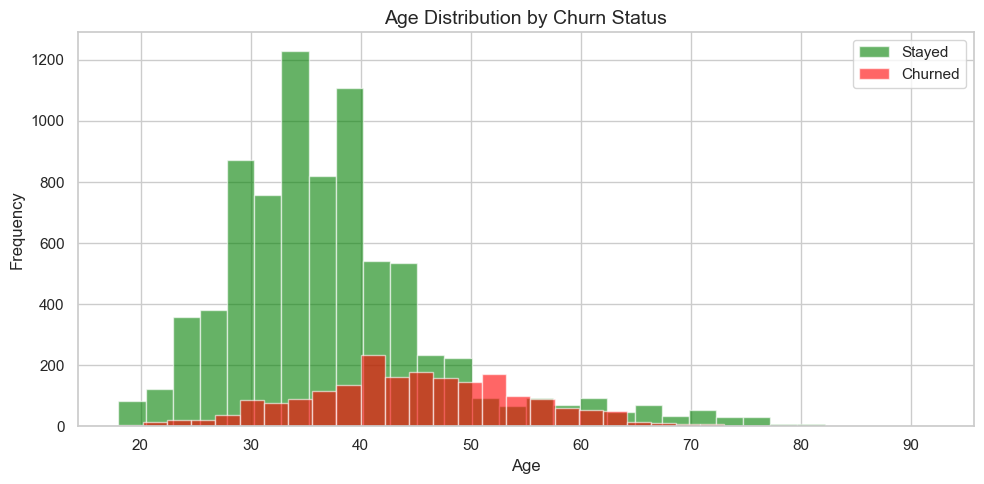

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

df[df['Exited'] == 0]['Age'].plot(kind='hist', bins=30, alpha=0.6, label='Stayed', color='green', ax=ax)
df[df['Exited'] == 1]['Age'].plot(kind='hist', bins=30, alpha=0.6, label='Churned', color='red', ax=ax)


ax.set_title('Age Distribution by Churn Status', fontsize=14)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('outputs/age_distribution.png', bbox_inches='tight')
plt.show()

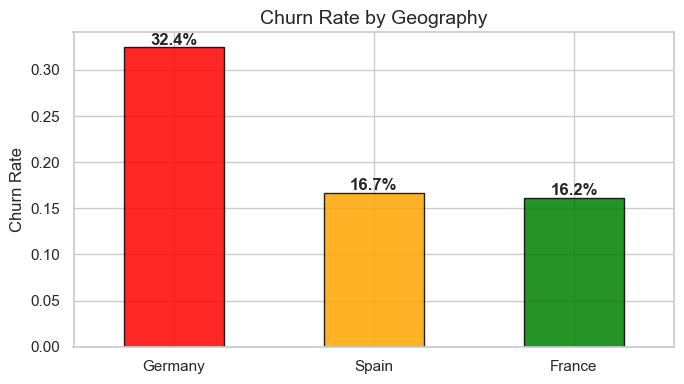

In [9]:
geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
geo_churn.plot(kind='bar', color=['red', 'orange', 'green'],
               edgecolor='black', alpha=0.85, ax=ax)
ax.set_title('Churn Rate by Geography', fontsize=14)
ax.set_ylabel('Churn Rate')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.003),
                ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/churn_by_geography.png', bbox_inches='tight')
plt.show()

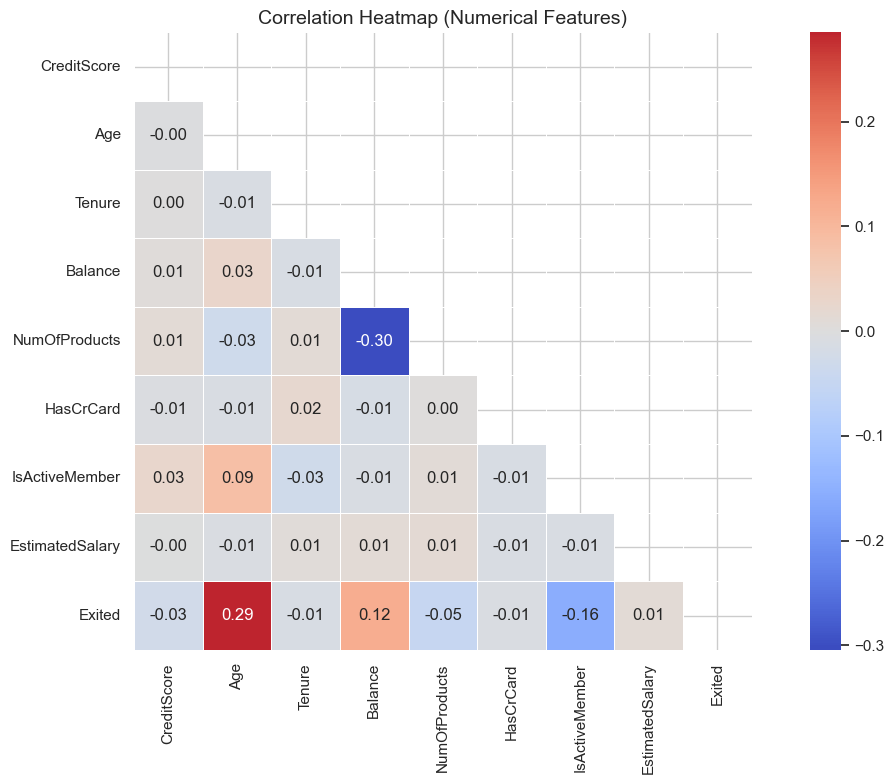

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(
    columns=['RowNumber', 'CustomerId']
).columns

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            mask=mask, ax=ax)

ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [11]:
target_corr = corr_matrix['Exited'].drop('Exited').sort_values(key=abs, ascending=False)
print('feature correlations with exited (target):')
print(target_corr.round(3))

feature correlations with exited (target):
Age                0.285
IsActiveMember    -0.156
Balance            0.119
NumOfProducts     -0.048
CreditScore       -0.027
Tenure            -0.014
EstimatedSalary    0.012
HasCrCard         -0.007
Name: Exited, dtype: float64


data processing


In [12]:
df_model = df.copy()
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_model.drop(columns=cols_to_drop, inplace=True)





In [13]:
le = LabelEncoder()
df_model['Geography'] = le.fit_transform(df_model['Geography'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

print(df_model.head(10))

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   
5          645          2       1   44       8  113755.78              2   
6          822          0       1   50       7       0.00              2   
7          376          1       0   29       4  115046.74              4   
8          501          0       1   44       4  142051.07              2   
9          684          0       1   27       2  134603.88              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58      

In [14]:
df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [15]:
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Features:', list(X.columns))

Feature matrix shape: (10000, 10)
Target shape: (10000,)
Features: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


train test


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y

)
print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
print('\nTrain churn rate:', y_train.mean().round(3))
print('Test churn rate: ', y_test.mean().round(3))

Training set:  8000 samples
Test set:      2000 samples

Train churn rate: 0.204
Test churn rate:  0.204


random forest

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test) 


In [18]:
def evaluate_model(y_true, y_pred, model_name='Model'):
    print(f"=== {model_name} ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")
    print(f"MAE:       {mean_absolute_error(y_true, y_pred):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Stayed", "Churned"]))


y_pred = rf.predict(X_test)

print("Baseline model results:")
evaluate_model(y_test, y_pred, "Random Forest")


Baseline model results:
=== Random Forest ===
Accuracy:  0.8640
Precision: 0.7824
Recall:    0.4595
F1:        0.5789
MAE:       0.1360

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



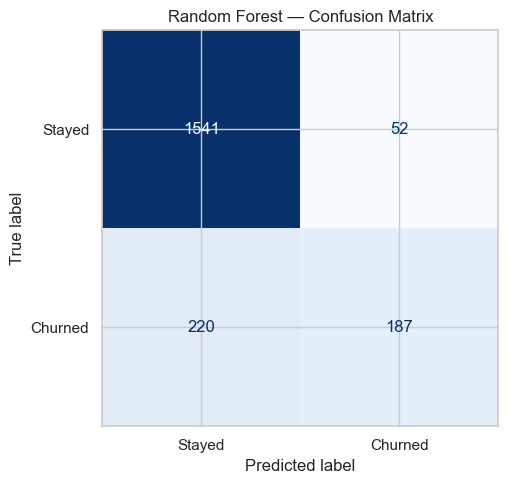

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/baseline_RF_confusion_matrix.png", bbox_inches="tight")
plt.show()

Class imbalance

In [20]:
counts = y_train.value_counts()
ratio = counts[0] / counts[1]

print(f"class 0 (stayed): {counts[0]}")
print(f"class 1 (churned):    {counts[1]}")
print(f"Ratio: {ratio:.2f}:1")

scale_pos_weight = ratio
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}")

class 0 (stayed): 6370
class 1 (churned):    1630
Ratio: 3.91:1

scale_pos_weight = 3.91


XGboost / Gridsearch

In [21]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("\nbest parameters:", grid_search.best_params_)
print(f"CV F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
CV F1: 0.6007


In [22]:
best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("-XGBoost (Tuned) ")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_xgb):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["Stayed", "Churned"]))


-XGBoost (Tuned) 
Accuracy:  0.8020
Precision: 0.5099
Recall:    0.6953
F1:        0.5884
MAE:       0.1980
              precision    recall  f1-score   support

      Stayed       0.91      0.83      0.87      1593
     Churned       0.51      0.70      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.80      0.81      2000



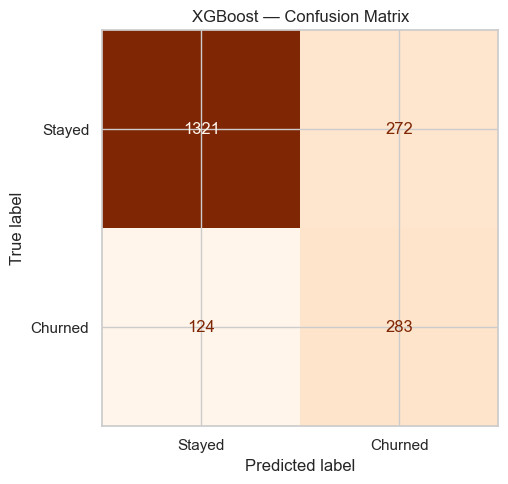

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm2 = confusion_matrix(y_test, y_pred_xgb)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["Stayed", "Churned"])
disp2.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/xgb_confusion_matrix.png", bbox_inches="tight")
plt.show()

Feature Importance

In [ ]:
feat_imp = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind="barh", ax=ax, color="blue", edgecolor="black", alpha=0.8)
ax.set_title("Feature Importance — XGBoost")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", bbox_inches="tight")
plt.show()

NameError: name 'pd' is not defined

SHAP


ExactExplainer explainer: 201it [00:16,  4.83it/s]                         


SHAP values shape: (200, 10, 2)


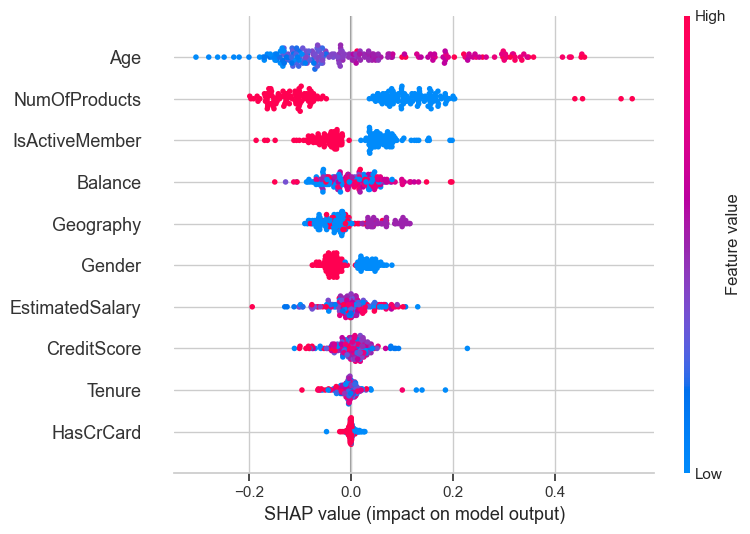

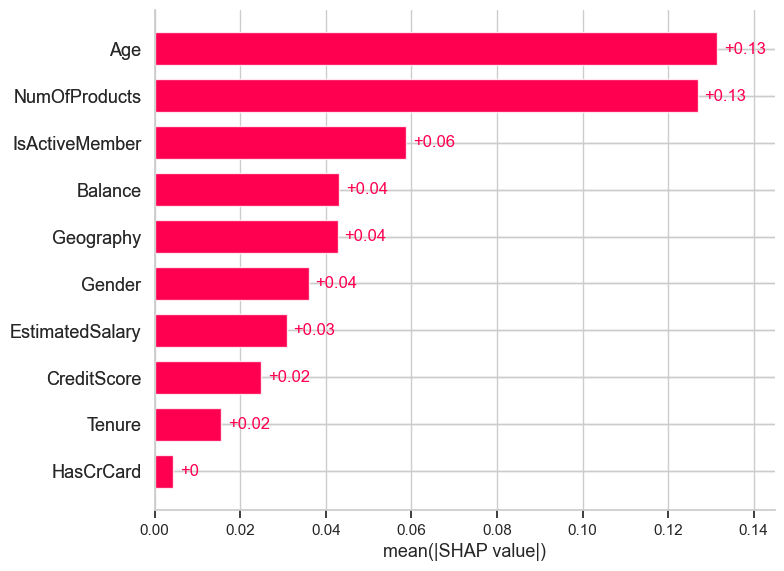

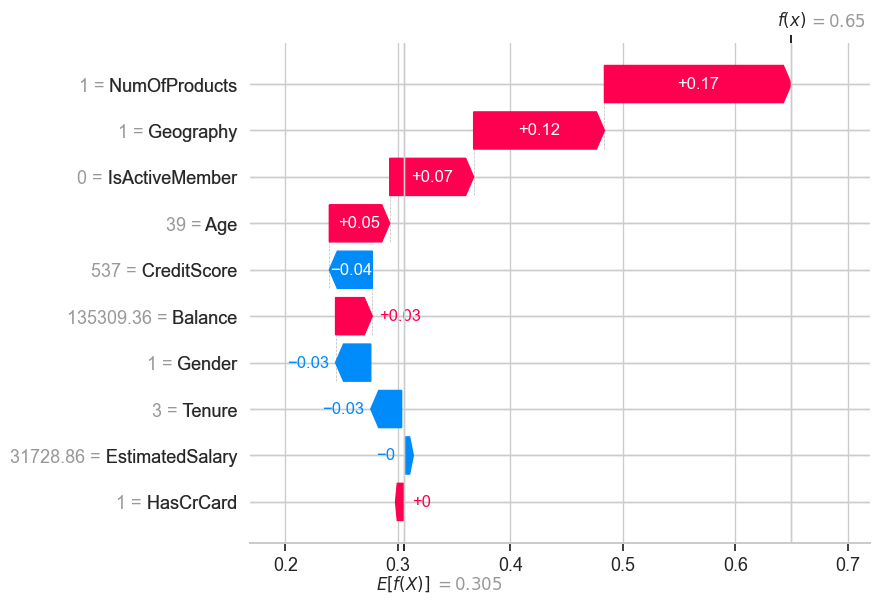

In [ ]:

explainer = shap.Explainer(best_xgb.predict_proba, X_train)
X_sample = X_test.sample(200, random_state=42)

shap_values = explainer(X_sample)

print("SHAP values shape:", shap_values.values.shape)

shap.summary_plot(shap_values[:,:,1], X_sample)
shap.plots.bar(shap_values[:,:,1])
shap.plots.waterfall(shap_values[0,:,1])